In [26]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammadshahidazeem/customer-churn-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-churn-dataset' dataset.
Path to dataset files: /kaggle/input/customer-churn-dataset


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [28]:
os.listdir(path)

['customer_churn_dataset-testing-master.csv',
 'customer_churn_dataset-training-master.csv']

In [29]:
train_df=pd.read_csv(path+"/customer_churn_dataset-training-master.csv")
test_df=pd.read_csv(path+"/customer_churn_dataset-testing-master.csv")

In [30]:
train_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [31]:
test_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [32]:
print("Training Columns")
print(train_df.columns.tolist())

Training Columns
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


In [33]:
print("Testing Columns")
print(test_df.columns.tolist())

Testing Columns
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


In [34]:
train_df.columns.tolist()==test_df.columns.tolist()

True

In [35]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [36]:
train_df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [37]:
null_rows_train = train_df[train_df.isnull().any(axis=1)]
display(null_rows_train)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
train_df.columns.tolist()

['CustomerID',
 'Age',
 'Gender',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Subscription Type',
 'Contract Length',
 'Total Spend',
 'Last Interaction',
 'Churn']

In [39]:
train_df.drop(index=199295, inplace=True)
print("Row at index 199295 dropped from train_df.")

Row at index 199295 dropped from train_df.


In [40]:
train_df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [41]:
train_df=train_df.drop(columns=['CustomerID'])
test_df=test_df.drop(columns=['CustomerID'])

In [45]:
X_train=train_df.drop(columns=['Churn'])
y_train=train_df['Churn']
X_test=test_df.drop(columns=['Churn'])
y_test=test_df['Churn']

In [46]:
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (440832, 10)
Shape of y_train: (440832,)
Shape of X_test: (64374, 10)
Shape of y_test: (64374,)


In [48]:
categorical_features=X_train.select_dtypes(include=['object','category']).columns.tolist()
numerical_features=X_train.select_dtypes(include=['int64','float64']).columns.tolist()

In [49]:
print("Categorical Features:",categorical_features)
print("Numerical Features:",numerical_features)

Categorical Features: ['Gender', 'Subscription Type', 'Contract Length']
Numerical Features: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']


In [50]:
for col in categorical_features:
    print(f"\n{col}")
    print(train_df[col].value_counts())


Gender
Gender
Male      250252
Female    190580
Name: count, dtype: int64

Subscription Type
Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

Contract Length
Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64


In [52]:
X_train = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True
)

In [53]:
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [55]:
X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

In [56]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression
Accuracy : 0.5711467362599807
Precision: 0.5250843097034384
Recall   : 0.9905880038041518
F1 Score : 0.6863518104045717
Confusion Matrix:
[[ 6561 27320]
 [  287 30206]]


In [58]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [59]:
print("Decision Tree")

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree
Accuracy : 0.5033243234846366
Precision: 0.48813836437662295
Recall   : 0.998688223526711
F1 Score : 0.6557564142594128
Confusion Matrix:
[[ 1948 31933]
 [   40 30453]]


In [60]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [61]:
print("Random Forest")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
Accuracy : 0.503464131481654
Precision: 0.4882076606115021
Recall   : 0.9985898402912143
F1 Score : 0.6557977257064094
Confusion Matrix:
[[ 1960 31921]
 [   43 30450]]


In [63]:
# Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

# Decision Tree
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

# Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

In [64]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.571147,0.525084,0.990588,0.686352
1,Decision Tree,0.503324,0.488138,0.998688,0.655756
2,Random Forest,0.503464,0.488208,0.998590,0.655798


In [65]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

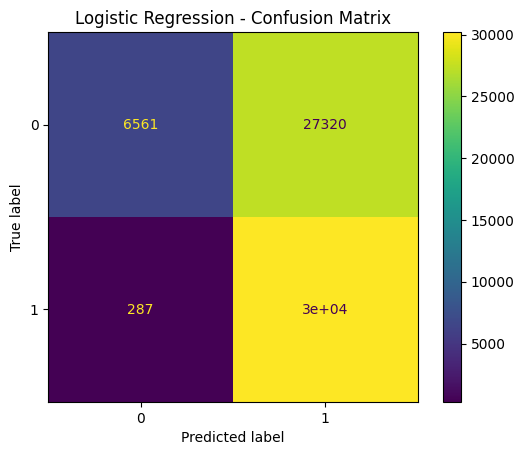

In [66]:
#Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

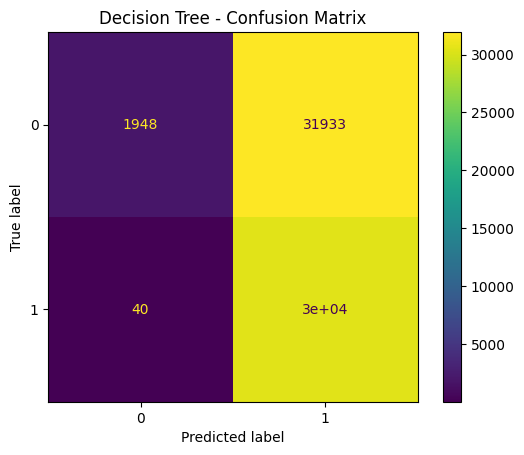

In [68]:
#Regression Tree
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

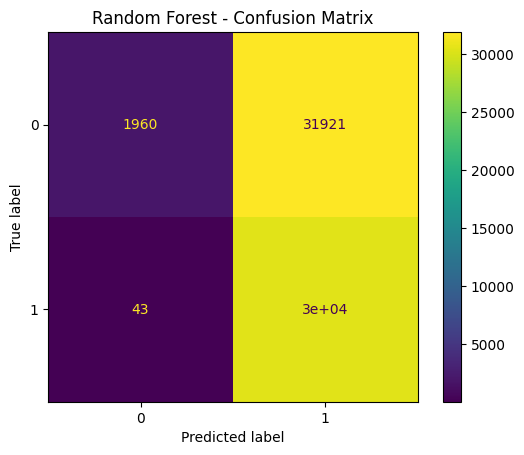

In [69]:
#Rabdom Forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

### **BEST MODEL SELECTED:LOGISTIC REGRESSION**
